# Implicit vs explicit steady-state model

This notebook compares two variants of the PEMFC steady-state model:

| Model | MEA temperature |
|---|---|
| **Explicit** | Estimated analytically from current density (0.7 V efficiency approximation) |
| **Implicit** | Solved self-consistently so that the heat released by the cell matches the heat conducted through the GDL stack |

Both models use the same `set_initial_conditions` / `solve` API:

```python
model = mrpd.ExplicitSteadyStateModel()   # or ImplicitSteadyStateModel()
conditions = mrpd.CellConditions(...)
state = model.set_initial_conditions(cell, conditions)
state = model.solve(cell, conditions, state)
```

The two sections below compare:
1. **Polarization curve** — voltage and MEA temperature over the full current range.
2. **Quasi-steady time series** (requires `monocell_datas_03Mar2026_08h10.csv`) — voltage, MEA temperature, and wall-clock time on a real test-bench log.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd

## 1 — Cell assembly

MEA62 parameters from `02_parameter_estimation.ipynb`.

In [2]:
fixed_parameters = {
    'radius-carbon': 25e-9,
    'ionomer-E-act-cond': 15e6,
    'n_s': 2,
    'ionomer-k1': 8.5,
    'ionomer-k2': 5.4,
    'ionomer-k3': 5.4,
    'gdl-porosity': 0.6,
    'pt-wt-percent': 0.4,
    'ch-height': 1e-3,
    'gdl-thickness': 150e-6,
    'gdl-theta': 120.,
    'gdl-eff-diff-ratio': 0.3,
    'cl-abs-perm': 1e-13,
    'wet-transition': 0.4,
    'pt-loading': .3e-2,
    'ic-ratio': 1.4,
    'ecsa': 60e3,
    'memb-thickness': 12e-6,
    'memb-water-diff': 2e-10,
    'E-act-memb-diff': 20e6,
    'E-act-memb-abs': 20e6,
    'cl-theta': 97.,
    'cl-thermal-cond': 0.22,
    'cl-pore-diameter': 40e-9,
}

estimated_parameters = {
    'elec-resistance': 3.2018410582982336e-06,
    'alpha-c': 0.8804552030152384,
    'memb-cond-correction': 10.194306339919532,
    'B_ch': 1.3173241932454605,
    'ionomer-cond-corr': 0.16788866561668214,
    'i0-c': 0.0013603559102389256,
    'memb-cond-exp': 1.6472232706926844,
    'Sh': 0.7956740630180096,
    'E-act-ca': 73404895.12308666,
    'memb-equiv-weight': 707.0461410229138,
    'memb-E-act-cond': 12920411.386859203,
    'gdl-thermal-cond': 0.10151383504290674,
    'gamma-c': 0.7815865333197847,
    'memb-abs-constant': 3.680688030527334e-05,
    'ix-corr': 2.0,
    'ionomer-cond-exp': 1.0,
    'tcr': 0.0009955086394233985,
    'gdl-abs-perm': 9.999999010000095e-12,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    class NewPermModel(mrpd.HydrogenPermeationModel):
        def permeation_flux(self, membrane_thickness, partial_pressure_h2,
                            temperature, pressure_difference, water_vol_fraction):
            return self.permeability_correction_factor * (
                15.7e-9 * np.exp(-20280 / 8.3415 / temperature) +
                water_vol_fraction * 45e-9 * np.exp(-18930 / 8.3145 / temperature)
            ) / 1000 * 100 / 1e5 * partial_pressure_h2 / membrane_thickness

    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params['memb-equiv-weight'],
            dry_density=2000.,
            conductivity_exp=params['memb-cond-exp'],
            conductivity_activation_energy=params['memb-E-act-cond'],
            conductivity_correction=params['memb-cond-correction'],
            reference_water_diffusivity=params['memb-water-diff'],
            reference_water_absorption_coefficient=params['memb-abs-constant'],
            water_diffusivity_activation_energy=params['E-act-memb-diff'],
            water_absorption_activation_energy=params['E-act-memb-abs'],
        ),
        dry_thickness=params['memb-thickness'],
        h2_permeation_model=NewPermModel(permeability_correction_factor=params['ix-corr']),
    )

    orr_kinetics = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = mrpd.DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: mrpd.GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=mrpd.PorousGasDiffusionModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: mrpd.FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=mrpd.ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = mrpd.PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'],
        ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'],
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'],
        contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'],
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    return mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=mrpd.FuelCellSide(
            cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
            thermal_contact_resistance=params['tcr'],
        ),
        an=mrpd.FuelCellSide(
            cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
            thermal_contact_resistance=params['tcr'],
        ),
        membrane=membrane,
    )


cell = create_cell(params)
print(f"Cell assembled — membrane thickness: {cell.membrane.dry_thickness*1e6:.0f} µm")

Cell assembled — membrane thickness: 12 µm


## 2 — Polarization curve comparison

Standard operating conditions at 353 K.  Both models accept a full current-density
array in one vectorised call — no looping required.

In [3]:
T = 353.15   # K
i_arr = np.linspace(500, 22000, 40)   # A/m²

cond = mrpd.CellConditions(
    current_density=i_arr,
    cell_temperature=T,
    ca=mrpd.SideConditions(
        inlet_temperature=T, outlet_pressure=1.5e5,
        dry_o2_mole_fraction=0.21, inlet_relative_humidity=0.5, stoichiometry=2.0,
    ),
    an=mrpd.SideConditions(
        inlet_temperature=T, outlet_pressure=1.5e5,
        dry_h2_mole_fraction=1.0, inlet_relative_humidity=0.5, stoichiometry=1.5,
    ),
)

explicit_model = mrpd.ExplicitSteadyStateModel()
implicit_model = mrpd.ImplicitSteadyStateModel()

t0 = time.perf_counter()
state_exp = explicit_model.set_initial_conditions(cell, cond)
state_exp = explicit_model.solve(cell, cond, state_exp)
t_explicit = time.perf_counter() - t0

t0 = time.perf_counter()
state_imp = implicit_model.set_initial_conditions(cell, cond)
state_imp = implicit_model.solve(cell, cond, state_imp)
t_implicit = time.perf_counter() - t0

V_exp, T_mea_exp = state_exp.cell_voltage, state_exp.mea_temperature
V_imp, T_mea_imp = state_imp.cell_voltage, state_imp.mea_temperature

print(f"Explicit : {t_explicit*1e3:.0f} ms")
print(f"Implicit : {t_implicit*1e3:.0f} ms  (×{t_implicit/t_explicit:.1f} slower)")
print(f"Max ΔV   = {np.max(np.abs(V_exp - V_imp))*1e3:.2f} mV")
print(f"Max ΔT   = {np.max(np.abs(T_mea_exp - T_mea_imp)):.3f} K")

Explicit : 1 ms
Implicit : 45 ms  (×41.6 slower)
Max ΔV   = 263.78 mV
Max ΔT   = 8.365 K


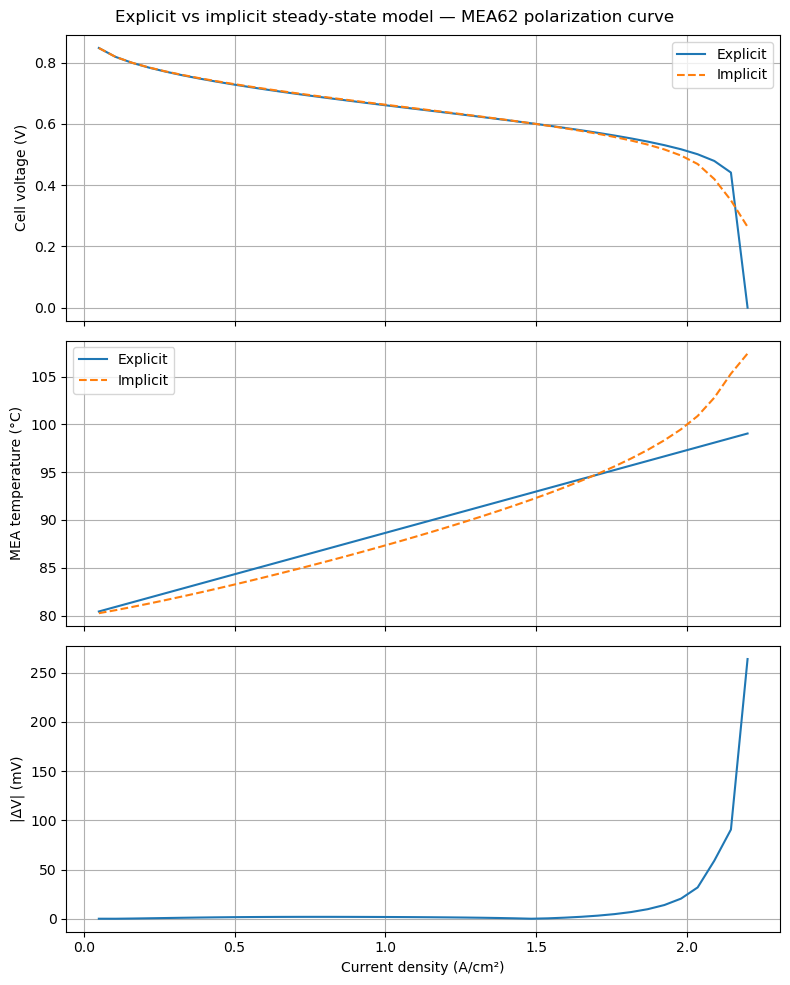

In [4]:
i_plot = i_arr * 1e-4   # A/cm²

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(i_plot, V_exp, label='Explicit')
axes[0].plot(i_plot, V_imp, '--', label='Implicit')
axes[0].set_ylabel('Cell voltage (V)')
axes[0].legend()

axes[1].plot(i_plot, T_mea_exp - 273.15, label='Explicit')
axes[1].plot(i_plot, T_mea_imp - 273.15, '--', label='Implicit')
axes[1].set_ylabel('MEA temperature (°C)')
axes[1].legend()

axes[2].plot(i_plot, np.abs(V_exp - V_imp) * 1e3)
axes[2].set_ylabel('|ΔV| (mV)')
axes[2].set_xlabel('Current density (A/cm²)')

for ax in axes:
    ax.grid()

fig.suptitle('Explicit vs implicit steady-state model — MEA62 polarization curve')
fig.tight_layout()
plt.show()

## 3 — Quasi-steady time-series comparison

Replays the MEA62 test-bench log sample-by-sample via a single vectorised
`solve` call for each model.  Both condition fields and current density are
passed as arrays, so all active samples are evaluated simultaneously.

> **Note:** Requires `monocell_datas_03Mar2026_08h10.csv` in the notebook directory.

In [ ]:
import os

CSV_PATH = 'monocell_datas_03Mar2026_08h10.csv'
csv_available = os.path.exists(CSV_PATH)

if not csv_available:
    print("CSV not found — skipping time-series section.")
else:
    df = pd.read_csv(CSV_PATH, sep=';', skiprows=6, encoding='latin1')
    df = df.rename(columns=lambda c: c.strip())
    old_columns = list(df.columns)
    df = df.reset_index()
    df.columns = ['Time(s)'] + old_columns[1:] + ['_extra']
    df = df.drop(columns=['_extra'])
    df['Time(h)'] = (df['Time(s)'] - df['Time(s)'].iloc[0]) / 3600.
    print(df[['Time(h)', 'I_Pile(A)', 'U_Pile(V)', 'T_pile(°C)']].describe())

In [ ]:
if csv_available:
    CELL_AREA = 25e-4   # m², active area per cell
    N_CELLS   = 1
    I_MIN     = 0.5     # A

    active     = (df['I_Pile(A)'] > I_MIN).to_numpy()
    active_idx = np.flatnonzero(active)
    rows       = df.iloc[active_idx]

    # Pack all active samples into one CellConditions — every field is an
    # array of shape (n_active,), so all samples are evaluated in one call.
    cond_ts = mrpd.CellConditions(
        current_density=np.maximum(rows['I_Pile(A)'].to_numpy(), 1e-4) / CELL_AREA,
        cell_temperature=(rows['T_pile(°C)'] + 273.15).to_numpy(),
        ca=mrpd.SideConditions(
            inlet_temperature=(rows['T_Air_in(°C)'] + 273.15).to_numpy(),
            outlet_pressure=(rows['P_Air_Out(bara)'] * 1e5).to_numpy(),
            dry_o2_mole_fraction=0.21,
            stoichiometry=rows['Stoeckio_air_calc'].to_numpy(),
            inlet_relative_humidity=(rows['RH_Air_calc(%)'] / 100.).to_numpy(),
        ),
        an=mrpd.SideConditions(
            inlet_temperature=(rows['T_H2_In(°C)'] + 273.15).to_numpy(),
            outlet_pressure=(rows['P_h2_out(bara)'] * 1e5).to_numpy(),
            dry_h2_mole_fraction=1.0,
            stoichiometry=rows['Stoeckio_h2_calc'].to_numpy(),
            inlet_relative_humidity=(rows['RH_h2_calc(%)'] / 100.).to_numpy(),
        ),
    )

    cell_ts      = create_cell(params)
    exp_model_ts = mrpd.ExplicitSteadyStateModel()
    imp_model_ts = mrpd.ImplicitSteadyStateModel()

    t0 = time.perf_counter()
    state_exp_ts = exp_model_ts.set_initial_conditions(cell_ts, cond_ts)
    state_exp_ts = exp_model_ts.solve(cell_ts, cond_ts, state_exp_ts)
    t_exp_ts = time.perf_counter() - t0

    t0 = time.perf_counter()
    state_imp_ts = imp_model_ts.set_initial_conditions(cell_ts, cond_ts)
    state_imp_ts = imp_model_ts.solve(cell_ts, cond_ts, state_imp_ts)
    t_imp_ts = time.perf_counter() - t0

    # Map back to the full time axis (NaN for excluded samples)
    n = len(df)
    cell_v_exp_ts = np.full(n, np.nan);  cell_v_exp_ts[active_idx] = state_exp_ts.cell_voltage
    cell_v_imp_ts = np.full(n, np.nan);  cell_v_imp_ts[active_idx] = state_imp_ts.cell_voltage
    T_mea_exp_ts  = np.full(n, np.nan);  T_mea_exp_ts[active_idx]  = state_exp_ts.mea_temperature
    T_mea_imp_ts  = np.full(n, np.nan);  T_mea_imp_ts[active_idx]  = state_imp_ts.mea_temperature

    n_s = len(active_idx)
    print(f"Explicit : {t_exp_ts*1e3:.0f} ms  ({t_exp_ts/n_s*1e3:.2f} ms/sample)")
    print(f"Implicit : {t_imp_ts*1e3:.0f} ms  ({t_imp_ts/n_s*1e3:.2f} ms/sample)  (×{t_imp_ts/t_exp_ts:.1f} slower)")
    print(f"Max ΔV   = {np.nanmax(np.abs(cell_v_exp_ts - cell_v_imp_ts))*1e3:.2f} mV")
    print(f"Max ΔT   = {np.nanmax(np.abs(T_mea_exp_ts - T_mea_imp_ts)):.3f} K")

In [ ]:
if csv_available:
    time_h     = df['Time(h)'].to_numpy()
    measured_V = df['U_Pile(V)'].to_numpy() / N_CELLS

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    axes[0].plot(time_h, df['I_Pile(A)'].to_numpy() / CELL_AREA * 1e-4)
    axes[0].set_ylabel('Current density (A/cm²)')

    axes[1].plot(time_h, measured_V, label='Measured', alpha=0.6)
    axes[1].plot(time_h, cell_v_exp_ts, label='Explicit')
    axes[1].plot(time_h, cell_v_imp_ts, '--', label='Implicit')
    axes[1].set_ylabel('Cell voltage (V)')
    axes[1].set_ylim([0.55, 0.95])
    axes[1].legend()

    axes[2].plot(time_h, T_mea_exp_ts - 273.15, label='Explicit')
    axes[2].plot(time_h, T_mea_imp_ts - 273.15, '--', label='Implicit')
    axes[2].set_ylabel('MEA temperature (°C)')
    axes[2].legend()

    axes[3].plot(time_h, np.abs(cell_v_exp_ts - cell_v_imp_ts) * 1e3)
    axes[3].set_ylabel('|V_exp − V_imp| (mV)')
    axes[3].set_xlabel('Time (h)')

    for ax in axes:
        ax.grid()

    fig.suptitle('Explicit vs implicit — MEA62 quasi-steady time series')
    fig.tight_layout()
    plt.show()